In [1]:
import os
print(os.getcwd())


/Users/maceli/ifood_cs/code/notebook


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.functions import (
    load_data,
    check_key_uniqueness,
    merge_df,
    load_orders,
    process_orders_pandas
)
from utilities.descritiva import (
    plot_indicadores_mes_plataforma,
    gerar_stats,
    pedidos_group,
    criacao_ordens

)

In [3]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet")#.drop([ "delivery_address_district", "delivery_address_country",'customer_name','active','created_at','delivery_address_external_id'], axis=1)
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform
0,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,4d12c9e2cf2720b3e638c060eed65a35b5cc1e3b7eaf66...,2019-01-29T19:44:19.000Z,31eb01fc4bc7c297a403f662e55cf9e59dc1e9f4dc551f...,11.49,IOS
1,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,aeb2c47a6a45243ba227c4fcc2b073c2da30b0637ba136...,2019-01-20T14:05:52.000Z,7201c79e26943fe0ef09e3d15240eb90f6b4e8c9bba2f6...,22.90,IOS
2,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,fe61b80037e191b6b79523c9c4e69b2a73c50bda954fd7...,2019-01-10T23:49:30.000Z,c9c7729d1fafde77f4139389972fb715ebe3f05bb1ec79...,68.30,IOS
3,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,95bbceba7b5cd56a8442a6d4d4edb760d310608440d9e2...,2019-01-17T22:28:57.000Z,721195cbf745297a40ef05fcd85265054a2415c70fe41d...,61.00,IOS
4,2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8...,target,True,2018-01-07T23:37:48.252Z,ES,4d12c9e2cf2720b3e638c060eed65a35b5cc1e3b7eaf66...,2019-01-18T18:41:24.000Z,0fe14d829a5bbc40e3ea93ab13da7e18d81945e9c480fb...,14.99,IOS


In [ ]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"], utc=True)
df['unique_order_hash'] = pd.util.hash_pandas_object(
        df[['customer_id', 'order_created_at','order_id']],
        index=False
    )
df = df.drop(columns=['order_id'], errors='ignore')
df["order_created_month"] = df["order_created_at"].dt.month
id_both_monht=df[df['order_created_month']==12]['customer_id'].unique()
df = df[df['customer_id'].isin(id_both_monht)].reset_index(drop=True)
df["day_month_year"] = df["order_created_at"].dt.strftime("%d-%m-%Y")
df["weekday"] = df["order_created_at"].dt.day_name()
df["hour"] = df["order_created_at"].dt.hour

df["day"] = df["order_created_at"].dt.day


In [5]:
df_stats_mes = (
        df.groupby(['order_created_month','is_target'])
          .agg(
              total_clientes=('customer_id', 'nunique')))

df_stats_mes  

total_clientes
order_created_month is_target                
1                   control             29978
                    target              38705
12                  control             29978
                    target              38705

Criando dias da semana, dia, hora

In [6]:
summary_mes=gerar_stats(df,['origin_platform'])
summary_mes

,order_created_month,origin_platform,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,IOS,30713,115179,6085496.98,41.52,45.19,49.77
1,1,ANDROID,30431,99537,4298068.58,41.14,39.05,35.15
2,1,DESKTOP,12131,38237,1767403.03,16.40,15.00,14.45
3,1,WINDOWS_PHONE,696,1941,76507.94,0.94,0.76,0.63
4,12,IOS,30124,67879,3551960.22,42.18,44.52,48.91
5,12,ANDROID,29710,60824,2611801.61,41.60,39.90,35.96
6,12,DESKTOP,10949,22552,1051531.40,15.33,14.79,14.48
7,12,WINDOWS_PHONE,640,1198,47436.77,0.90,0.79,0.65


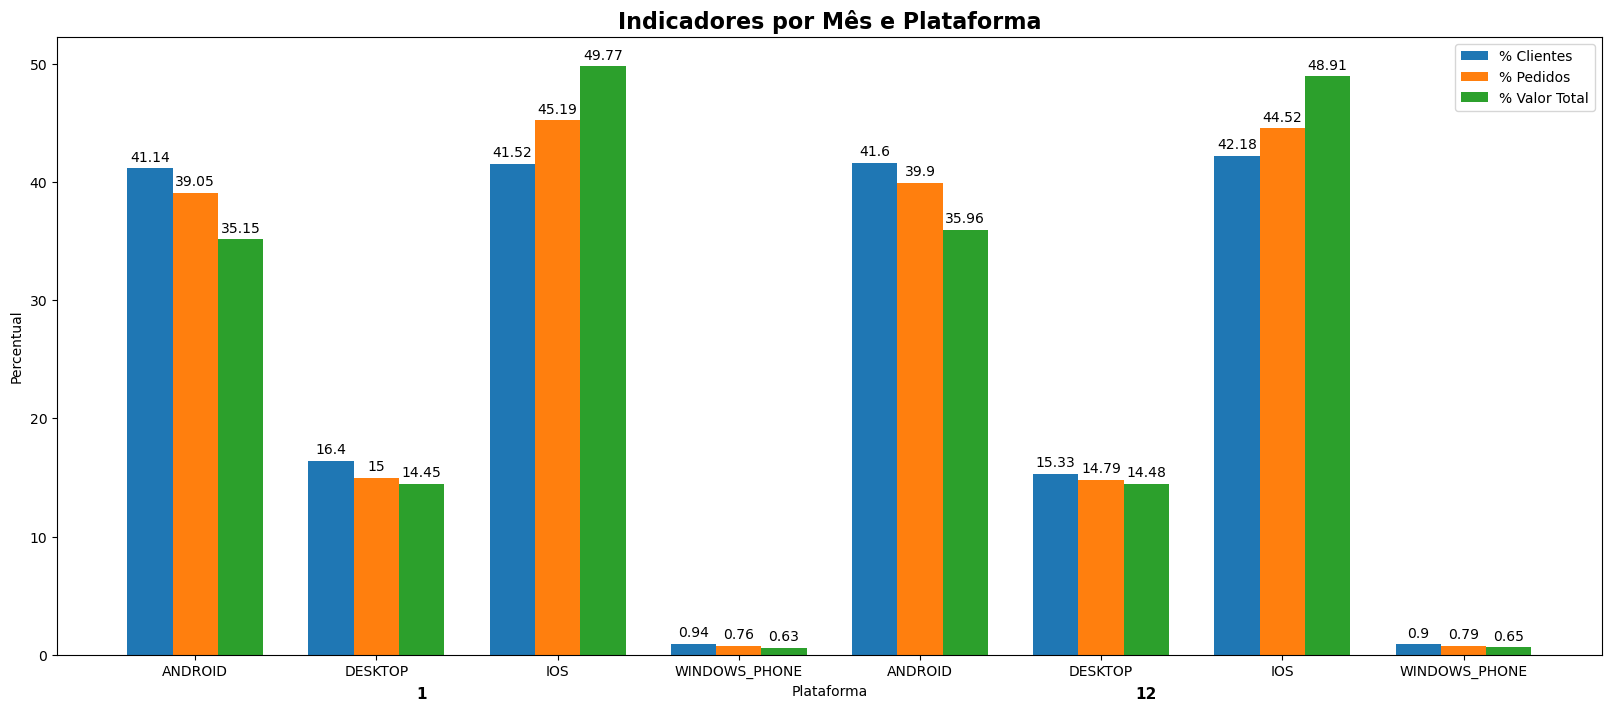

In [ ]:
plot_indicadores_mes_plataforma(summary_mes)

Numero de pedidos por cliente exatamente um ou mais de um

In [8]:
pedidos_group(df)

,order_created_month,categoria_pedidos,total_clientes,total_pedidos,total_amount,avg_amount_por_cliente,perc_clientes,perc_pedidos,perc_amount
0,1,1_pedido,24056,24056,1140546.74,47.412152,35.02,9.44,9.33
1,1,2+_pedidos,44627,230838,11086929.79,248.435472,64.98,90.56,90.67
2,12,1_pedido,37161,37161,1785259.63,48.041216,54.11,24.38,24.58
3,12,2+_pedidos,31522,115292,5477470.37,173.766587,45.89,75.62,75.42


In [24]:
df, dias_0=criacao_ordens(df)
print('Media da diferenca em dias entre a primeira e segunda ordem, nao levando em consideracao o periodo do mes',dias_0)

Media da diferenca em dias entre a primeira e segunda ordem, nao levando em consideracao o periodo do mes 5.820365336379992


In [25]:
summary_mes = gerar_stats(
    df[df['rank_month'] == 2],
    ['days_until_next_order']
)

summary_mes.head()

,order_created_month,days_until_next_order,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,-999.0,13234,13234,631015.84,29.65,29.65,29.47
1,1,0.0,6296,6296,292816.13,14.11,14.11,13.68
2,1,1.0,4961,4961,238087.21,11.12,11.12,11.12
3,1,2.0,3500,3500,167213.59,7.84,7.84,7.81
4,1,3.0,2620,2620,126200.79,5.87,5.87,5.89


In [34]:
df_ = df[
    [
        'customer_id',
        'order_created_at',
        'order_created_month',
        'is_target',
        'rank_month',
        'order_total_amount',
        'days_between_orders',
        'days_since_first_order_month',
        'unique_order_hash'
    ]
].copy()  # evita SettingWithCopyWarning

df_['converteu'] = False
df_['desconto'] = 0

#df_ = df_.loc[
    #df_['customer_id'] == '002ca070253de5dd983f577e0156dae30cfe981198bce5c7815755748343594c'
#]

df = df_.reset_index(drop=True)




In [ ]:
import numpy as np

window_days = 8
desconto_p = 0.10  # 10%

# clientes com primeira compra (rank 1)
df_d = df[df['rank_month'].isin([1])][['customer_id', 'is_target']].drop_duplicates()

# flag de conversão: segunda compra no mês 1 dentro da janela
df['converteu'] = (
    (df['order_created_month'] == 1) &
    (df['rank_month'] == 2) &
    (df['days_between_orders'] < window_days)
)

df['valor_desconto'] = np.where(
    (df['is_target'] == 'target'),
    df['order_total_amount'] * desconto_p,
    0
)


# ❌ aqui estava o erro: você usou 'desconto', mas criou 'valor_desconto'
df['valor_final'] = df['order_total_amount'] - df['valor_desconto']

# só segundas compras que converteram
df_conv = df[(df['rank_month'] == 2) & (df['converteu'] == True)]

# junta base de 1ª compra com info da 2ª compra (se tiver)
a = df_d[['customer_id', 'is_target']].merge(
    df_conv[['customer_id', 'converteu',
             'order_total_amount', 'valor_desconto']],
    on='customer_id',
    how='left'  # mantém todo mundo da coorte de primeira compra
)
a['converteu'] = a['converteu'].fillna(False)
a=a.fillna(0)
# agora SIM, salva o resultado do groupby:
resumo = a.groupby('is_target', as_index=False).agg(
    total_clientes=('customer_id', 'nunique'),
    clientes_convertidos=('converteu', 'sum'),
    #total_ordens=('unique_order_hash', 'count'),
    total_amount=('order_total_amount', 'sum'),
    total_desconto=('valor_desconto', 'sum'),
    #avg_amount=('order_total_amount', 'mean')
).assign(
            taxa_conversao=lambda x: (x['clientes_convertidos'] / x['total_clientes'] * 100).round(2),
            total_amount_liquido=lambda x: x['total_amount'] - x['total_desconto'],
           # custo_medio_desconto=lambda x: (x['total_desconto'] / x['clientes_convertidos']).round(2) if x['clientes_convertidos'] > 0 else 0,
            window_dias=window_days
        ).reset_index()

resumo

In [42]:
import numpy as np
import pandas as pd

def analisar_teste_ab(df, descontos=[0.10], janelas=[8], variavel_adicional=None, min_perc_clientes=5):
    """
    Analisa teste A/B completo com múltiplos descontos, janelas e variáveis adicionais
    """
    
    pd.set_option('future.no_silent_downcasting', True)
    
    resultados = []
    
    for desconto_p in descontos:
        for window_days in janelas:
            print(f"\n=== Processando: Desconto {desconto_p*100}% | Janela {window_days} dias ===")
            
            # VERIFICAR se a variável adicional existe
            colunas_base = ['customer_id', 'is_target']
            if variavel_adicional and variavel_adicional in df.columns:
                colunas_base.append(variavel_adicional)
                print(f"✅ Variável '{variavel_adicional}' encontrada no DataFrame principal")
            else:
                print(f"❌ Variável '{variavel_adicional}' NÃO encontrada")
                # Se não encontrar, continuar sem a variável
                variavel_adicional = None
            
            # clientes com primeira compra (rank 1)
            df_d = df[df['rank_month'].isin([1])][colunas_base].drop_duplicates()
            print(f"Primeira compra - colunas: {df_d.columns.tolist()}")
            
            # flag de conversão
            df_temp = df.copy()
            df_temp['converteu'] = (
                (df_temp['order_created_month'] == 1) &
                (df_temp['rank_month'] == 2) &
                (df_temp['days_between_orders'] <= window_days)
            )

            df_temp['valor_desconto'] = np.where(
                (df_temp['is_target'] == 'target'),
                df_temp['order_total_amount'] * desconto_p,
                0
            )

            # só segundas compras que converteram
            df_conv = df_temp[(df_temp['rank_month'] == 2) & (df_temp['converteu'] == True)]
            print(f"Segunda compra - colunas: {df_conv.columns.tolist()}")

            # Colunas para merge - usar APENAS as que existem
            colunas_merge = ['customer_id', 'converteu', 'order_total_amount', 'valor_desconto']
            if variavel_adicional and variavel_adicional in df_conv.columns:
                colunas_merge.append(variavel_adicional)
                print(f"✅ Adicionando '{variavel_adicional}' ao merge")
            else:
                print(f"❌ '{variavel_adicional}' não encontrada na segunda compra")

            # Filtrar colunas_merge para apenas as que existem em df_conv
            colunas_merge = [col for col in colunas_merge if col in df_conv.columns]
            print(f"Colunas para merge: {colunas_merge}")

            # junta base de 1ª compra com info da 2ª compra
            a = df_d.merge(
                df_conv[colunas_merge],
                on='customer_id',
                how='left'
            )
            
            print(f"Após merge - colunas: {a.columns.tolist()}")
            
            a['converteu'] = a['converteu'].fillna(False)
            a = a.fillna(0)
            a['converteu'] = a['converteu'].astype(bool)
            
            # DEFINIR colunas para groupby - APENAS as que existem
            groupby_cols = ['is_target']
            if variavel_adicional and variavel_adicional in a.columns:
                groupby_cols.append(variavel_adicional)
                print(f"✅ Agrupando por: {groupby_cols}")
            else:
                print(f"❌ Agrupando apenas por is_target")
            
            # resumo estatístico
            resumo = a.groupby(groupby_cols, as_index=False).agg(
                total_clientes=('customer_id', 'nunique'),
                clientes_convertidos=('converteu', 'sum'),
                total_amount=('order_total_amount', 'sum'),
                total_desconto=('valor_desconto', 'sum'),
            ).assign(
                taxa_conversao=lambda x: (x['clientes_convertidos'] / x['total_clientes'] * 100).round(2),
                total_amount_liquido=lambda x: x['total_amount'] - x['total_desconto'],
                window_dias=window_days,
                desconto_percentual=desconto_p * 100
            ).reset_index(drop=True)
            
            print(f"Resultado - colunas: {resumo.columns.tolist()}")
            print(resumo.head())
            
            resultados.append(resumo)
    
    if resultados:
        resultado_final = pd.concat(resultados, ignore_index=True)
        return resultado_final
    else:
        return pd.DataFrame()

# TESTE
resultado = analisar_teste_ab(df, 
                             descontos=[0.10], 
                             janelas=[0], 
                             variavel_adicional='origin_platform',
                             min_perc_clientes=5)

resultado.head(20)


=== Processando: Desconto 10.0% | Janela 0 dias ===
❌ Variável 'origin_platform' NÃO encontrada
Primeira compra - colunas: ['customer_id', 'is_target']
Segunda compra - colunas: ['customer_id', 'order_created_at', 'order_created_month', 'is_target', 'rank_month', 'order_total_amount', 'days_between_orders', 'days_since_first_order_month', 'unique_order_hash', 'converteu', 'desconto', 'valor_desconto']
❌ 'None' não encontrada na segunda compra
Colunas para merge: ['customer_id', 'converteu', 'order_total_amount', 'valor_desconto']
Após merge - colunas: ['customer_id', 'is_target', 'converteu', 'order_total_amount', 'valor_desconto']
❌ Agrupando apenas por is_target
Resultado - colunas: ['is_target', 'total_clientes', 'clientes_convertidos', 'total_amount', 'total_desconto', 'taxa_conversao', 'total_amount_liquido', 'window_dias', 'desconto_percentual']
  is_target  total_clientes  clientes_convertidos  total_amount  \
0   control           29978                  3047     140493.68   
1

,is_target,total_clientes,clientes_convertidos,total_amount,total_desconto,taxa_conversao,total_amount_liquido,window_dias,desconto_percentual
0,control,29978,3047,140493.68,0.000,10.16,140493.680,0,10.0
1,target,38705,4683,214148.14,21414.814,12.10,192733.326,0,10.0


In [43]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

def analisar_teste_ab_com_estatistica(df, descontos=[0.10], janelas=[8]):
    """
    Analisa teste A/B completo com múltiplos descontos e janelas + análise estatística
    """
    
    # Configurar pandas para evitar warnings
    pd.set_option('future.no_silent_downcasting', True)
    
    resultados_detalhados = []
    resultados_estatisticos = []
    
    for desconto_p in descontos:
        for window_days in janelas:
            print(f"\n{'='*60}")
            print(f"🎯 ANÁLISE: Desconto {desconto_p*100:.0f}% | Janela {window_days} dias")
            print(f"{'='*60}")
            
            # clientes com primeira compra (rank 1)
            df_d = df[df['rank_month'].isin([1])][['customer_id', 'is_target']].drop_duplicates()

            # flag de conversão
            df_temp = df.copy()
            df_temp['converteu'] = (
                (df_temp['order_created_month'] == 1) &
                (df_temp['rank_month'] == 2) &
                (df_temp['days_between_orders'] <= window_days)
            )

            df_temp['valor_desconto'] = np.where(
                (df_temp['is_target'] == 'target'),
                df_temp['order_total_amount'] * desconto_p,
                0
            )

            # só segundas compras que converteram
            df_conv = df_temp[(df_temp['rank_month'] == 2) & (df_temp['converteu'] == True)]

            # junta base de 1ª compra com info da 2ª compra
            a = df_d[['customer_id', 'is_target']].merge(
                df_conv[['customer_id', 'converteu', 'order_total_amount', 'valor_desconto']],
                on='customer_id',
                how='left'
            )
            
            # Corrigir o warning do fillna
            a['converteu'] = a['converteu'].fillna(False)
            a = a.fillna(0)
            a['converteu'] = a['converteu'].astype(bool)  # Garantir que é boolean
            
            # RESULTADOS DETALHADOS
            resumo = a.groupby('is_target', as_index=False).agg(
                total_clientes=('customer_id', 'nunique'),
                clientes_convertidos=('converteu', 'sum'),
                total_amount=('order_total_amount', 'sum'),
                total_desconto=('valor_desconto', 'sum'),
            ).assign(
                taxa_conversao=lambda x: (x['clientes_convertidos'] / x['total_clientes'] * 100).round(2),
                total_amount_liquido=lambda x: x['total_amount'] - x['total_desconto'],
                window_dias=window_days,
                desconto_percentual=desconto_p * 100
            ).reset_index(drop=True)
            
            resultados_detalhados.append(resumo)
            
            # ANÁLISE ESTATÍSTICA
            print("\n--- ANÁLISE ESTATÍSTICA ---")
            conversoes_target = a[(a['is_target'] == 'target') & (a['converteu'])].shape[0]
            total_target = a[a['is_target'] == 'target'].shape[0]
            
            conversoes_control = a[(a['is_target'] == 'control') & (a['converteu'])].shape[0]
            total_control = a[a['is_target'] == 'control'].shape[0]
            
            total_geral = total_target + total_control
            
            print(f"Target: {total_target} ({total_target/total_geral:.1%})")
            print(f"Control: {total_control} ({total_control/total_geral:.1%})")
            
            # Teste Z
            if total_target > 0 and total_control > 0 and conversoes_target + conversoes_control > 0:
                count = [conversoes_target, conversoes_control]
                nobs = [total_target, total_control]
                
                z_stat, p_value = proportions_ztest(count, nobs)
                
                taxa_target = conversoes_target / total_target
                taxa_control = conversoes_control / total_control
                diferenca_absoluta = taxa_target - taxa_control
                lift_relativo = diferenca_absoluta / taxa_control if taxa_control > 0 else 0
                
                print(f"Conversão Target: {taxa_target:.3%}")
                print(f"Conversão Control: {taxa_control:.3%}")
                print(f"Diferença absoluta: {diferenca_absoluta:.3%}")
                print(f"Lift relativo: {lift_relativo:+.1%}")
                print(f"Z-statistic: {z_stat:.4f}")
                print(f"P-value: {p_value:.4f}")
                print(f"Significativo (p < 0.05): {p_value < 0.05}")
                
                # Intervalos de confiança
                ci_target = proportion_confint(conversoes_target, total_target, alpha=0.05)
                ci_control = proportion_confint(conversoes_control, total_control, alpha=0.05)
                
                print(f"IC Target: [{ci_target[0]:.3%}, {ci_target[1]:.3%}]")
                print(f"IC Control: [{ci_control[0]:.3%}, {ci_control[1]:.3%}]")
                
                # Salvar resultados
                resultados_estatisticos.append({
                    'desconto_percentual': desconto_p * 100,
                    'window_dias': window_days,
                    'taxa_target': taxa_target,
                    'taxa_control': taxa_control,
                    'diferenca_absoluta': diferenca_absoluta,
                    'lift_relativo': lift_relativo,
                    'z_stat': z_stat,
                    'p_value': p_value,
                    'significativo': p_value < 0.05,
                    'total_target': total_target,
                    'total_control': total_control
                })
            else:
                print("❌ Dados insuficientes para análise estatística")
    
    # Retornar resultados
    resultado_final = pd.concat(resultados_detalhados, ignore_index=True)
    resultados_estat_df = pd.DataFrame(resultados_estatisticos)
    
    return resultado_final, resultados_estat_df

# Exemplo de uso:
# resultados, estatisticas = analisar_teste_ab_com_estatistica(df, descontos=[0.10, 0.15], janelas=[5, 8, 10])

In [20]:
resultados, estatisticas = analisar_teste_ab_com_estatistica(df, descontos=[0.10], janelas=[0,1,2,5, 8])


🎯 ANÁLISE: Desconto 10% | Janela 0 dias

--- ANÁLISE ESTATÍSTICA ---
Target: 38705 (56.4%)
Control: 29978 (43.6%)
Conversão Target: 12.099%
Conversão Control: 10.164%
Diferença absoluta: 1.935%
Lift relativo: +19.0%
Z-statistic: 7.9584
P-value: 0.0000
Significativo (p < 0.05): True
IC Target: [11.774%, 12.424%]
IC Control: [9.822%, 10.506%]

🎯 ANÁLISE: Desconto 10% | Janela 1 dias

--- ANÁLISE ESTATÍSTICA ---
Target: 38705 (56.4%)
Control: 29978 (43.6%)
Conversão Target: 21.325%
Conversão Control: 17.906%
Diferença absoluta: 3.419%
Lift relativo: +19.1%
Z-statistic: 11.1445
P-value: 0.0000
Significativo (p < 0.05): True
IC Target: [20.917%, 21.733%]
IC Control: [17.472%, 18.340%]

🎯 ANÁLISE: Desconto 10% | Janela 2 dias

--- ANÁLISE ESTATÍSTICA ---
Target: 38705 (56.4%)
Control: 29978 (43.6%)
Conversão Target: 27.978%
Conversão Control: 23.704%
Diferença absoluta: 4.274%
Lift relativo: +18.0%
Z-statistic: 12.6476
P-value: 0.0000
Significativo (p < 0.05): True
IC Target: [27.531%, 28.4

In [47]:
from statsmodels.stats.power import TTestIndPower
import math

def calcular_minimo_para_significancia(df, desconto_p, window_days, poder_desejado=0.8, alpha=0.05):
    """
    Calcula tamanho mínimo de amostra e MDE (diferença mínima detectável)
    para o teste A/B, respeitando o MESMO ratio entre controle e target
    observado no experimento.
    """
    # 1) Base: clientes com 1ª compra
    df_d = df[df['rank_month'].isin([1])][['customer_id', 'is_target']].drop_duplicates()
    
    # 2) Marca conversão (segunda compra no mês 1 dentro da janela)
    df_temp = df.copy()
    df_temp['converteu'] = (
        (df_temp['order_created_month'] == 1) &
        (df_temp['rank_month'] == 2) &
        (df_temp['days_between_orders'] <=window_days)
    )
    
    df_conv = df_temp[(df_temp['rank_month'] == 2) & (df_temp['converteu'] == True)]
    
    a = df_d[['customer_id', 'is_target']].merge(
        df_conv[['customer_id', 'converteu']],
        on='customer_id',
        how='left'
    )
    a['converteu'] = a['converteu'].fillna(False)
    
    # 3) Taxas atuais
    conversoes_target = a[(a['is_target'] == 'target') & (a['converteu'])].shape[0]
    total_target = a[a['is_target'] == 'target'].shape[0]
    
    conversoes_control = a[(a['is_target'] == 'control') & (a['converteu'])].shape[0]
    total_control = a[a['is_target'] == 'control'].shape[0]
    
    if total_target == 0 or total_control == 0:
        return "Dados insuficientes"
    
    taxa_target = conversoes_target / total_target
    taxa_control = conversoes_control / total_control
    
    # 4) Effect size (Cohen's h) - target vs control
    effect_size = 2 * math.asin(math.sqrt(taxa_target)) - 2 * math.asin(math.sqrt(taxa_control))
    
    # 5) Ratio real do experimento: grupo2/grupo1 = target/control
    ratio_real = total_target / total_control
    
    analysis = TTestIndPower()
    
    # 6) Amostra mínima NECESSÁRIA para ter o poder desejado (mantendo o MESMO ratio)
    # nobs1 = controle, nobs2 = target
    amostra_minima_control = analysis.solve_power(
        effect_size=effect_size,
        power=poder_desejado,
        alpha=alpha,
        ratio=ratio_real   # target / control
    )
    amostra_minima_target = amostra_minima_control * ratio_real
    amostra_minima_total = amostra_minima_control + amostra_minima_target
    
    # 7) Effect size mínimo detectável (MDE) com a AMOSTRA ATUAL (mesmo ratio)
    mde_amostra_atual = analysis.solve_power(
        effect_size=None,
        nobs1=total_control,        # grupo 1 = controle
        power=poder_desejado,
        alpha=alpha,
        ratio=ratio_real            # target / control
    )
    
    print(f"=== ANÁLISE DE PODER PARA {desconto_p*100:.0f}% DESCONTO | JANELA {window_days} DIAS ===")
    print(f"📊 SITUAÇÃO ATUAL:")
    print(f"   • Taxa Target:  {taxa_target:.3%}")
    print(f"   • Taxa Control: {taxa_control:.3%}")
    print(f"   • Diferença:    {(taxa_target - taxa_control):.3%}")
    print(f"   • Effect Size (Cohen's h): {effect_size:.4f}")
    print(f"   • Amostra atual: {total_target} Target + {total_control} Control = {total_target + total_control} total")
    print(f"   • Ratio real (Target/Control): {ratio_real:.2f}")
    
    print(f"\n🎯 PARA TER {poder_desejado:.0%} DE PODER (MANTENDO ESSE MESMO RATIO):")
    print(f"   • Controle mínimo: {amostra_minima_control:.0f}")
    print(f"   • Target mínimo:   {amostra_minima_target:.0f}")
    print(f"   • Total necessário: {amostra_minima_total:.0f} clientes")
    print(f"   • Faltam: {max(0, amostra_minima_total - (total_target + total_control)):.0f} clientes")
    
    diff_min_detectavel = calcular_diferenca_minima(taxa_control, mde_amostra_atual)
    
    print(f"\n📈 COM AMOSTRA ATUAL:")
    print(f"   • Effect Size mínimo detectável: {mde_amostra_atual:.4f}")
    print(f"   • Diferença mínima detectável (aprox): {diff_min_detectavel:.3%}")
    
    return {
        'amostra_minima_control': amostra_minima_control,
        'amostra_minima_target': amostra_minima_target,
        'amostra_total_minima': amostra_minima_total,
        'effect_size_atual': effect_size,
        'effect_size_minimo_detectavel': mde_amostra_atual,
        'diferenca_minima_detectavel': diff_min_detectavel,
        'ratio_real_target_control': ratio_real,
        'taxa_target': taxa_target,
        'taxa_control': taxa_control,
        'total_target': total_target,
        'total_control': total_control,
    }

def calcular_diferenca_minima(taxa_base, effect_size):
    """
    Converte effect size (Cohen's h) de volta para diferença em porcentagem,
    usando taxa_base como taxa do controle.
    """
    asin_p2 = math.asin(math.sqrt(taxa_base))
    asin_p1 = effect_size / 2 + asin_p2
    p1 = math.sin(asin_p1) ** 2
    return p1 - taxa_base


In [48]:
resultado = calcular_minimo_para_significancia(
    df=df,
    desconto_p=0.10,   # 10% de desconto
    window_days=0,     # janela de conversão de 5 dias
    poder_desejado=0.8,
    alpha=0.05
)


=== ANÁLISE DE PODER PARA 10% DESCONTO | JANELA 0 DIAS ===
📊 SITUAÇÃO ATUAL:
   • Taxa Target:  12.099%
   • Taxa Control: 10.164%
   • Diferença:    1.935%
   • Effect Size (Cohen's h): 0.0616
   • Amostra atual: 38705 Target + 29978 Control = 68683 total
   • Ratio real (Target/Control): 1.29

🎯 PARA TER 80% DE PODER (MANTENDO ESSE MESMO RATIO):
   • Controle mínimo: 3674
   • Target mínimo:   4743
   • Total necessário: 8417 clientes
   • Faltam: 0 clientes

📈 COM AMOSTRA ATUAL:
   • Effect Size mínimo detectável: 0.0216
   • Diferença mínima detectável (aprox): 0.661%


In [31]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

def analise_estatistica_conversao(df):
    """
    Realiza análise estatística completa da conversão entre grupos
    
    Parâmetros:
    df: DataFrame com as colunas 'is_target' e 'converteu'
    """
    
    # Calcular conversões e tamanhos dos grupos
    conversoes_target = len(df[(df['is_target'] == 'target') & (df['converteu'] == True)])
    total_target = len(df[df['is_target'] == 'target'])

    conversoes_control = len(df[(df['is_target'] == 'control') & (df['converteu'] == True)])
    total_control = len(df[df['is_target'] == 'control'])

    total_geral = total_target + total_control

    print("=== DISTRIBUIÇÃO DA AMOSTRA ===")
    print(f"Target: {total_target} ({total_target/total_geral:.1%})")
    print(f"Control: {total_control} ({total_control/total_geral:.1%})")
    print(f"Total: {total_geral}")

    # Teste Z para proporções
    count = [conversoes_target, conversoes_control]
    nobs = [total_target, total_control]

    z_stat, p_value = proportions_ztest(count, nobs)

    print(f"\n=== RESULTADOS DO TESTE A/B ===")
    print(f"Conversão Target: {conversoes_target/total_target:.3%}")
    print(f"Conversão Control: {conversoes_control/total_control:.3%}")
    print(f"Diferença absoluta: {(conversoes_target/total_target - conversoes_control/total_control):.3%}")

    # Calcular lift relativo
    taxa_control = conversoes_control/total_control
    lift_relativo = (conversoes_target/total_target - taxa_control) / taxa_control
    print(f"Lift relativo: {lift_relativo:+.1%}")

    print(f"Z-statistic: {z_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Diferença significativa: {p_value < 0.05}")

    # Intervalos de confiança
    ci_target = proportion_confint(conversoes_target, total_target, alpha=0.05)
    ci_control = proportion_confint(conversoes_control, total_control, alpha=0.05)

    print(f"\n=== INTERVALOS DE CONFIANÇA (95%) ===")
    print(f"Target: [{ci_target[0]:.3%}, {ci_target[1]:.3%}]")
    print(f"Control: [{ci_control[0]:.3%}, {ci_control[1]:.3%}]")

    # Verificar sobreposição dos intervalos
    sobreposicao = not (ci_target[1] < ci_control[0] or ci_control[1] < ci_target[0])
    print(f"Intervalos se sobrepõem: {sobreposicao}")
    
    # Retornar resultados como dicionário (opcional)
    resultados = {
        'conversoes_target': conversoes_target,
        'total_target': total_target,
        'conversoes_control': conversoes_control,
        'total_control': total_control,
        'taxa_target': conversoes_target/total_target,
        'taxa_control': conversoes_control/total_control,
        'z_stat': z_stat,
        'p_value': p_value,
        'significativo': p_value < 0.05,
        'lift_relativo': lift_relativo,
        'ci_target': ci_target,
        'ci_control': ci_control,
        'sobreposicao_intervalos': sobreposicao
    }
    
    return resultados

# Exemplo de uso:
# resultados = analise_estatistica_conversao(a)

In [32]:
resultado = calcular_minimo_para_significancia(df)

TypeError: calcular_minimo_para_significancia() missing 2 required positional arguments: 'desconto_p' and 'window_days'

In [ ]:
test1=analise_estatistica_conversao(resultado)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

df = a

# Calcular conversões e tamanhos dos grupos
conversoes_target = len(df[(df['is_target'] == 'target') & (df['converteu'] == True)])
total_target = len(df[df['is_target'] == 'target'])

conversoes_control = len(df[(df['is_target'] == 'control') & (df['converteu'] == True)])
total_control = len(df[df['is_target'] == 'control'])

total_geral = total_target + total_control

print("=== DISTRIBUIÇÃO DA AMOSTRA ===")
print(f"Target: {total_target} ({total_target/total_geral:.1%})")
print(f"Control: {total_control} ({total_control/total_geral:.1%})")
print(f"Total: {total_geral}")

# Teste Z para proporções
count = [conversoes_target, conversoes_control]
nobs = [total_target, total_control]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"\n=== RESULTADOS DO TESTE A/B ===")
print(f"Conversão Target: {conversoes_target/total_target:.3%}")
print(f"Conversão Control: {conversoes_control/total_control:.3%}")
print(f"Diferença absoluta: {(conversoes_target/total_target - conversoes_control/total_control):.3%}")

# Calcular lift relativo
taxa_control = conversoes_control/total_control
lift_relativo = (conversoes_target/total_target - taxa_control) / taxa_control
print(f"Lift relativo: {lift_relativo:+.1%}")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Diferença significativa: {p_value < 0.05}")

# Intervalos de confiança
ci_target = proportion_confint(conversoes_target, total_target, alpha=0.05)
ci_control = proportion_confint(conversoes_control, total_control, alpha=0.05)

print(f"\n=== INTERVALOS DE CONFIANÇA (95%) ===")
print(f"Target: [{ci_target[0]:.3%}, {ci_target[1]:.3%}]")
print(f"Control: [{ci_control[0]:.3%}, {ci_control[1]:.3%}]")

# Verificar sobreposição dos intervalos
sobreposicao = not (ci_target[1] < ci_control[0] or ci_control[1] < ci_target[0])
print(f"Intervalos se sobrepõem: {sobreposicao}")

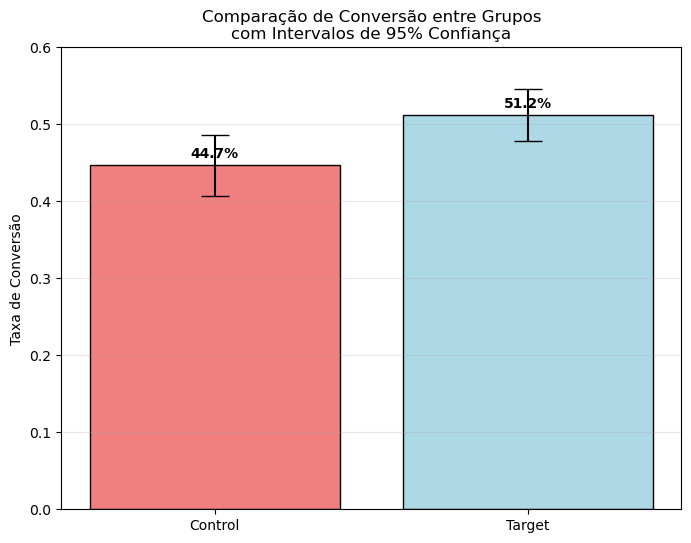

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dados dos grupos
grupos = ['Control', 'Target']
conversao = [0.44669, 0.51211]
erro = [(0.48967-0.40970)/2, (0.54538-0.47884)/2]  # semi-amplitude dos IC

plt.figure(figsize=(8, 6))
bars = plt.bar(grupos, conversao, yerr=erro, capsize=10, 
               color=['lightcoral', 'lightblue'], edgecolor='black')

plt.ylabel('Taxa de Conversão')
plt.title('Comparação de Conversão entre Grupos\ncom Intervalos de 95% Confiança')
plt.ylim(0, 0.6)

# Adicionar valores nas barras
for i, v in enumerate(conversao):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

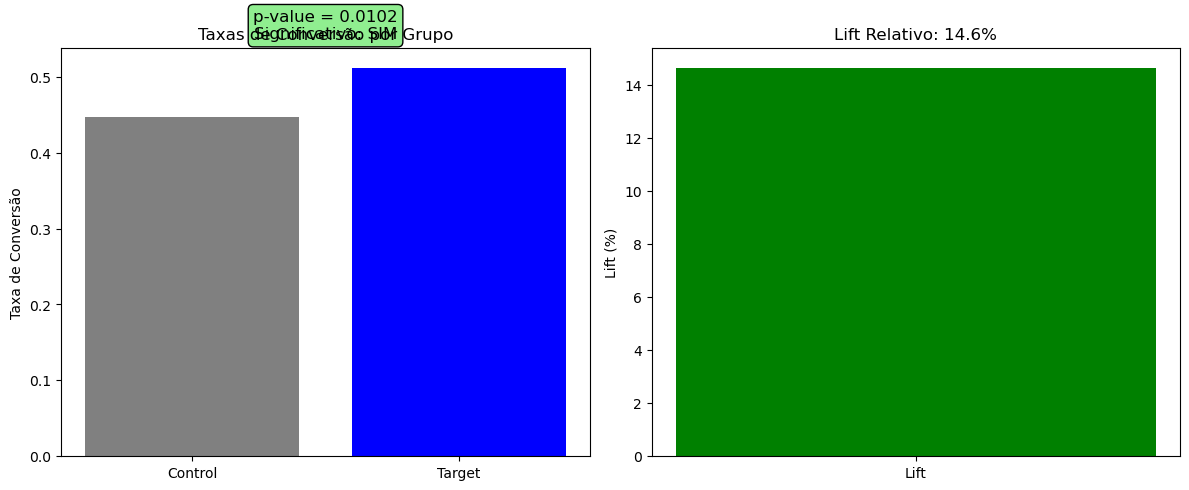

In [50]:
# Gráfico de comparação com destaque para o lift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Taxas de conversão
ax1.bar(['Control', 'Target'], conversao, color=['gray', 'blue'])
ax1.set_ylabel('Taxa de Conversão')
ax1.set_title('Taxas de Conversão por Grupo')

# Gráfico 2: Lift relativo
lift = (conversao[1] - conversao[0]) / conversao[0]
ax2.bar(['Lift'], [lift * 100], color='green')
ax2.set_ylabel('Lift (%)')
ax2.set_title(f'Lift Relativo: {lift:.1%}')

# Adicionar anotação de significância
ax1.text(0.5, 0.55, f'p-value = {0.0102:.4f}\nSignificativo: SIM', 
         ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))

plt.tight_layout()
plt.show()

In [51]:
# Calcular poder estatístico para verificar robustez
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()
poder = analysis.solve_power(
    effect_size=0.065,  # diferença absoluta
    nobs1=total_target,
    alpha=0.05,
    ratio=total_control/total_target
)
print(f"Poder estatístico: {poder:.1%}")

NameError: name 'total_target' is not defined

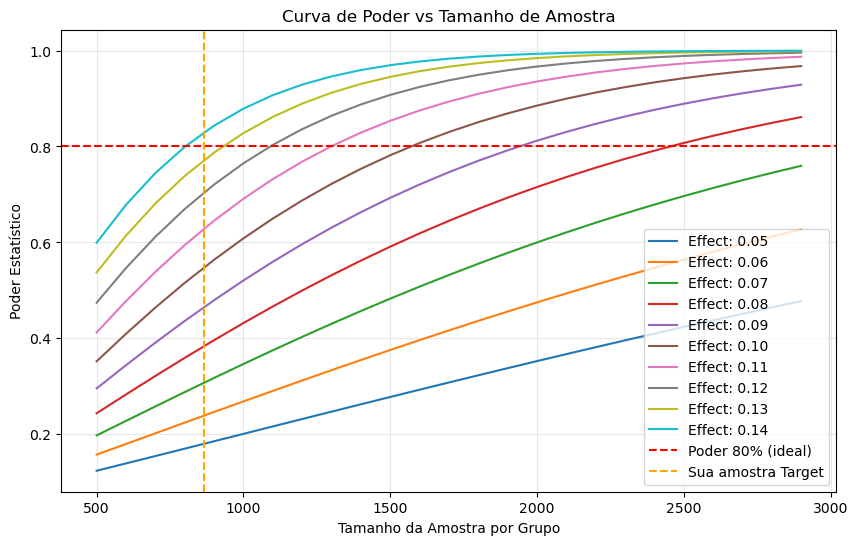

In [52]:
# Curva de poder para diferentes tamanhos de amostra
from statsmodels.stats.power import TTestIndPower
import numpy as np

effect_sizes = np.arange(0.05, 0.15, 0.01)
sample_sizes = range(500, 3000, 100)

analysis = TTestIndPower()

plt.figure(figsize=(10, 6))
for effect in effect_sizes:
    power = [analysis.solve_power(effect_size=effect, nobs1=n, alpha=0.05, ratio=1) 
             for n in sample_sizes]
    plt.plot(sample_sizes, power, label=f'Effect: {effect:.2f}')

plt.axhline(y=0.8, color='red', linestyle='--', label='Poder 80% (ideal)')
plt.axvline(x=867, color='orange', linestyle='--', label='Sua amostra Target')
plt.xlabel('Tamanho da Amostra por Grupo')
plt.ylabel('Poder Estatístico')
plt.title('Curva de Poder vs Tamanho de Amostra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline = 0.05
mde = 0.01  # 1pp

effect_size = proportion_effectsize(baseline + mde, baseline)

analysis = NormalIndPower()
n_por_grupo = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=60
)

n_por_grupo


4139.152657629758

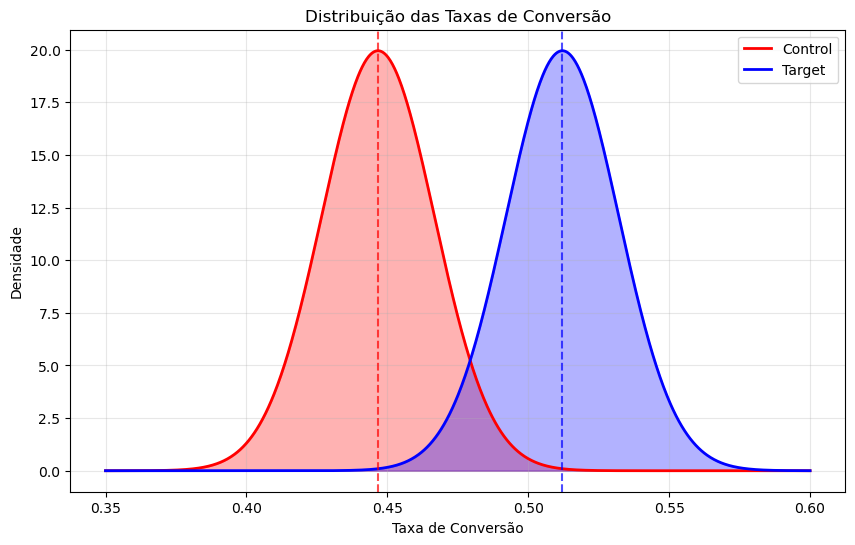

In [54]:
from scipy.stats import norm
import numpy as np

# Simular distribuições
x = np.linspace(0.35, 0.6, 1000)
y_control = norm.pdf(x, 0.44669, 0.02)  # média e desvio aproximado
y_target = norm.pdf(x, 0.51211, 0.02)

plt.figure(figsize=(10, 6))
plt.plot(x, y_control, label='Control', linewidth=2, color='red')
plt.plot(x, y_target, label='Target', linewidth=2, color='blue')
plt.fill_between(x, y_control, alpha=0.3, color='red')
plt.fill_between(x, y_target, alpha=0.3, color='blue')

plt.axvline(0.44669, color='red', linestyle='--', alpha=0.7)
plt.axvline(0.51211, color='blue', linestyle='--', alpha=0.7)

plt.xlabel('Taxa de Conversão')
plt.ylabel('Densidade')
plt.title('Distribuição das Taxas de Conversão')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# Para seu efeito de 6.54% com 80% de poder
from statsmodels.stats.power import NormalIndPower
import math

p1 = 0.51211  # Conversão Target
p2 = 0.44669  # Conversão Control
effect_size = 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))

analysis = NormalIndPower()
amostra_necessaria = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    ratio=60
)
print(f"Amostra necessária por grupo: {amostra_necessaria:.0f}")

Amostra necessária por grupo: 465


Para clientes com mais de um pedido no

Conversao imediata

In [ ]:
criacao_ordens(df, percentual_desconto=0.3)

Clientes com um unico pedido

In [ ]:
x = 1 # Exemplo: clientes com 2 pedidos

df_clientes_x_pedidos = (
    df[df['order_created_month'] == 12]
    .groupby(['customer_id', 'order_created_month'])
    .agg(
        quantidade_pedidos=('unique_order_hash', 'count')
    )
    .reset_index()
    .query(f'quantidade_pedidos == {x}')
)


In [ ]:
df_=df[['customer_id','order_created_month','merchant_id','order_created_at','days_until_next_order','rank_month','order_total_amount','amount_pct_change_from_previous','amount_diff_from_previous']]

In [ ]:
# 1. Valor das 2ªs ordens COM cupom
valor_segundas_ordens = df[df['rank_month'] == 2]['order_total_amount'].sum()

# 2. Custo total do cupom
custo_cupom = df[df['rank_month'] == 2]['%desconto'].sum()

# 3. Receita líquida das 2ªs ordens
receita_liquida = valor_segundas_ordens - custo_cupom

print("💰 IMPACTO DO CUPOM NA 2ª ORDEM:")
print(f"• Valor bruto das 2ªs ordens: R$ {valor_segundas_ordens:,.2f}")
print(f"• Custo do cupom: R$ {custo_cupom:,.2f}")
print(f"• Receita líquida: R$ {receita_liquida:,.2f}")
print(f"• % do custo sobre a receita: {(custo_cupom/valor_segundas_ordens*100):.1f}%")

In [ ]:


# Mostrar amostra
df[['customer_id', 'order_created_month','order_created_month' ,'rank_month', 'order_total_amount', '%desconto']].head(10)

In [ ]:
# Filtrar a base df apenas com os clientes que têm X pedidos
df_filtrado = df_[
    (df_['customer_id'].isin(df_clientes_x_pedidos['customer_id'])) #& 
    #(df['order_created_month'] == 12)
]
#df_filtrado.sort_values('amount_pct_change_from_previous')

In [ ]:
df_filtrado.head()

In [ ]:
from lifelines.statistics import logrank_test

# Supondo que você tem analysis_df com:
# - customer_id (identificador único)
# - grupo_ab ('A' ou 'B') 
# - tempo_ate_segunda (dias)
# - fez_segunda_ordem (True/False)

# Separar os grupos
grupo_a = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'target']
grupo_b = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'contol']

print(f"Grupo A: {len(grupo_a)} clientes")
print(f"Grupo B: {len(grupo_b)} clientes")

# Teste de Log-Rank
results = logrank_test(
    grupo_a['tempo_ate_segunda'], 
    grupo_b['tempo_ate_segunda'],
    event_observed_A=grupo_a['fez_segunda_ordem'],
    event_observed_B=grupo_b['fez_segunda_ordem']
)

print("\n=== TESTE DE LOG-RANK ===")
print(f"p-value: {results.p_value:.4f}")
print(f"Significativo (p < 0.05): {results.p_value < 0.05}")

if results.p_value < 0.05:
    print("✅ Há diferença significativa entre os grupos!")
else:
    print("❌ Não há diferença significativa entre os grupos")

In [ ]:
# Só precisa das contagens totais
from scipy.stats import chi2_contingency

# Criar tabela manualmente se não tiver o dataset
tabela = np.array([
    [len(grupo_a[grupo_a['fez_segunda_ordem'] == False]),  # Grupo A não converteu
     len(grupo_a[grupo_a['fez_segunda_ordem'] == True])],   # Grupo A converteu
    
    [len(grupo_b[grupo_b['fez_segunda_ordem'] == False]),  # Grupo B não converteu  
     len(grupo_b[grupo_b['fez_segunda_ordem'] == True])]    # Grupo B converteu
])

chi2, p_value, dof, expected = chi2_contingency(tabela)

In [ ]:
conversao_ab

In [ ]:
from scipy.stats import chi2_contingency

# Tabela de contingência
tabela = pd.crosstab(analysis_df['grupo_ab'], analysis_df['fez_segunda_ordem'])
print("=== TABELA DE CONTINGÊNCIA ===")
print(tabela)

# Teste Chi-Quadrado
chi2, p_value, dof, expected = chi2_contingency(tabela)
print(f"\n=== TESTE CHI-QUADRADO ===")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significativo (p < 0.05): {p_value < 0.05}")

In [ ]:
df.head()

In [ ]:
from datetime import datetime
data_inicio = datetime(2024, 1, 1)
data_inicio

In [ ]:
clientes_ativos_janeiro = df[df['order_created_month'] == 1]['customer_id'].unique()
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

In [ ]:
df=df[df['order_created_month'] == 1]

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Clientes ativos em janeiro de 2019 (fizeram pelo menos 1 pedido em jan/2019)
clientes_ativos_janeiro = df[
    (df['order_created_month'] == 1) & 
    (df['order_created_at'].dt.year == 2019)
]['customer_id'].unique()

print(f"Total de clientes ativos em janeiro de 2019: {len(clientes_ativos_janeiro)}")

# Filtrar TODOS os pedidos desses clientes
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

# Preparar dados para análise de sobrevivência CORRETA
analysis_data = []

for customer_id in clientes_ativos_janeiro:
    customer_orders = df_clientes_jan[df_clientes_jan['customer_id'] == customer_id].sort_values('order_created_at')
    
    # Primeira ordem do cliente em janeiro de 2019
    ordens_janeiro_2019 = customer_orders[
        (customer_orders['order_created_month'] == 1) & 
        (customer_orders['order_created_at'].dt.year == 2019)
    ]
    
    if len(ordens_janeiro_2019) >= 1:
        primeira_ordem_jan = ordens_janeiro_2019.iloc[0]
        data_primeira_ordem = primeira_ordem_jan['order_created_at']
        
        # Verificar se fez segunda ordem (em qualquer mês/ano)
        fez_segunda_ordem = len(customer_orders) >= 2
        
        if fez_segunda_ordem:
            segunda_ordem = customer_orders.iloc[1]
            data_segunda_ordem = segunda_ordem['order_created_at']
            
            # CORREÇÃO: Calcular tempo ENTRE 1ª e 2ª ordem
            tempo_ate_segunda = (data_segunda_ordem - data_primeira_ordem).days
            
            # Garantir que não seja negativo
            if tempo_ate_segunda < 0:
                print(f"AVISO: Tempo negativo para cliente {customer_id}")
                tempo_ate_segunda = 0
        else:
            # Cliente não fez segunda ordem - censurar após período razoável
            tempo_ate_segunda = 90  # Censurar em 90 dias
            fez_segunda_ordem = False
        
        analysis_data.append({
            'customer_id': customer_id,
            'grupo_ab': primeira_ordem_jan.get('grupo_ab', 'unknown'),
            'tempo_ate_segunda': tempo_ate_segunda,
            'fez_segunda_ordem': fez_segunda_ordem,
            'data_primeira_ordem': data_primeira_ordem
        })

# Criar DataFrame de análise
analysis_df = pd.DataFrame(analysis_data)

print(f"Clientes na análise: {len(analysis_df)}")
print(f"Clientes que fizeram 2ª ordem: {analysis_df['fez_segunda_ordem'].sum()}")
print(f"Taxa de conversão: {analysis_df['fez_segunda_ordem'].mean():.2%}")

# Verificar se há tempos negativos
if (analysis_df['tempo_ate_segunda'] < 0).any():
    print("⚠️  AVISO: Ainda há tempos negativos!")
    print(analysis_df[analysis_df['tempo_ate_segunda'] < 0])

# Aplicar Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=analysis_df['tempo_ate_segunda'],
    event_observed=analysis_df['fez_segunda_ordem']
)

# Plotar
plt.figure(figsize=(12, 8))
kmf.plot_survival_function()
plt.title('Tempo entre 1ª e 2ª Ordem\n(Clientes Janeiro 2019)')
plt.ylabel('Probabilidade de Ainda Não Ter Feito 2ª Ordem')
plt.xlabel('Dias desde a Primeira Ordem')
plt.grid(True)
plt.show()

# Estatísticas
print(f"\n--- Estatísticas ---")
print(f"Mediana de tempo até 2ª ordem: {kmf.median_survival_time_} dias")
for dias in [1, 3, 7, 15, 30]:
    conversao = (1 - kmf.predict(dias)) * 100
    print(f"Conversão em {dias} dias: {conversao:.1f}%")

In [ ]:
second_orders = df_f[df_f['rank_month'] == 2]

In [ ]:
df_f

In [ ]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month', 'days_since_first_order_month'], ascending=[True, True])
          .reset_index(drop=True)
    )
df_g[df_g['order_created_month']==12]
#df_g[df_g['order_created_month']==12]['total_ordem'].sum()


In [ ]:
df.head()

In [ ]:
gerar_stats(df,['day']).head()

In [ ]:
import streamlit as st

df.to_parquet(BASE_PATH / "gold" / "df_app.parquet", index=False)
estado = st.selectbox("Escolha o estado", df["weekday"].unique())
#mes = st.selectbox("Escolha o mês", df["month"].unique())

df_filtrado = df[(df["weekday"] == estado) #& (df["month"] == mes)
                 ]
st.dataframe(df_filtrado)


In [ ]:
df_pub_u=process_orders_pandas(df_pub_u)

In [ ]:
df_pub_un = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()

In [ ]:
df_pub_un = df[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()